# XGBoost Pipeline
Implements the XGBoost baseline as per `pipeline_design.txt` and prompt instructions.

In [1]:
import pandas as pd
import numpy as np
import json
import os
import joblib
import time
import sklearn
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import sys

print(f"Python: {sys.version}")
print(f"pandas: {pd.__version__}")
print(f"xgboost: {xgb.__version__}")

Python: 3.13.9 (tags/v3.13.9:8183fa5, Oct 14 2025, 14:09:13) [MSC v.1944 64 bit (AMD64)]
pandas: 2.3.3
xgboost: 3.4.1


In [2]:
sys.path.append('.')
from config import SEED
print(f"Shared SEED: {SEED}")

Shared SEED: 42


In [3]:
out_dir = 'outputs/xgboost'
os.makedirs(out_dir, exist_ok=True)

In [4]:
# Load data and splits
print("Loading data...")
df = pd.read_parquet('cleaned_dataset.parquet')
feature_cols = [c for c in df.columns if c != 'label']

with open('split_indices.json', 'r') as f:
    splits = json.load(f)

X_train = df.loc[splits['train_idx'], feature_cols].values
y_train = df.loc[splits['train_idx'], 'label'].values
X_val = df.loc[splits['val_idx'], feature_cols].values
y_val = df.loc[splits['val_idx'], 'label'].values
X_test = df.loc[splits['test_idx'], feature_cols].values
y_test = df.loc[splits['test_idx'], 'label'].values

Loading data...


In [5]:
# Preprocessing
# No preprocessing needed for XGBoost (no scaling)
scaler = None
joblib.dump(scaler, os.path.join(out_dir, 'scaler.joblib'))
print("Null scaler saved.")

Null scaler saved.


In [6]:
# Train XGBoost
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
scale_pos_weight = num_neg / num_pos
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=10,
    random_state=SEED,
    n_jobs=-1
)

print("Training XGBoost...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
print("Training complete.")

scale_pos_weight: 0.1830
Training XGBoost...


Training complete.


In [7]:
# Evaluate metrics
print("Evaluating on test split...")
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
malware_f1 = f1_score(y_test, y_pred, pos_label=1)
cm = confusion_matrix(y_test, y_pred).tolist()
report = classification_report(y_test, y_pred, output_dict=True)

metrics = {
    'accuracy': acc,
    'macro_f1': macro_f1,
    'malware_f1': malware_f1,
    'confusion_matrix': cm,
    'classification_report': report
}
with open(os.path.join(out_dir, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=4)

Evaluating on test split...


In [8]:
# Benchmark inference time
_ = xgb_model.predict(X_test)

print("Benchmarking inference time...")
single_sample = X_test[0:1]
single_times = []
for _ in range(100):
    start = time.perf_counter()
    xgb_model.predict(single_sample)
    single_times.append(time.perf_counter() - start)

batch_times = []
for _ in range(100):
    start = time.perf_counter()
    xgb_model.predict(X_test)
    batch_times.append(time.perf_counter() - start)

timing = {
    'n_jobs_used': -1,
    'single_sample_latency_sec': {'mean': np.mean(single_times), 'std': np.std(single_times)},
    'batch_throughput_sec': {'mean': np.mean(batch_times), 'std': np.std(batch_times)},
    'batch_size': len(X_test)
}
with open(os.path.join(out_dir, 'timing.json'), 'w') as f:
    json.dump(timing, f, indent=4)

Benchmarking inference time...


In [9]:
# Measure model size
model_path = os.path.join(out_dir, 'model.json')
xgb_model.save_model(model_path)
file_size_bytes = os.path.getsize(model_path)

dump = xgb_model.get_booster().get_dump()
num_trees = len(dump)
total_nodes = sum(tree.count('\n') for tree in dump)

size_info = {
    'file_size_bytes': file_size_bytes,
    'file_size_mb': file_size_bytes / (1024 * 1024),
    'structural_complexity': {
        'num_trees': num_trees,
        'total_nodes_approx': total_nodes
    }
}
with open(os.path.join(out_dir, 'size.json'), 'w') as f:
    json.dump(size_info, f, indent=4)

In [10]:
# Save artifacts
preds_df = pd.DataFrame({'y_true': y_test, 'y_pred': y_pred, 'y_pred_proba': y_pred_proba})
preds_df.to_csv(os.path.join(out_dir, 'test_predictions.csv'), index=False)
print("All artifacts saved successfully.")

All artifacts saved successfully.


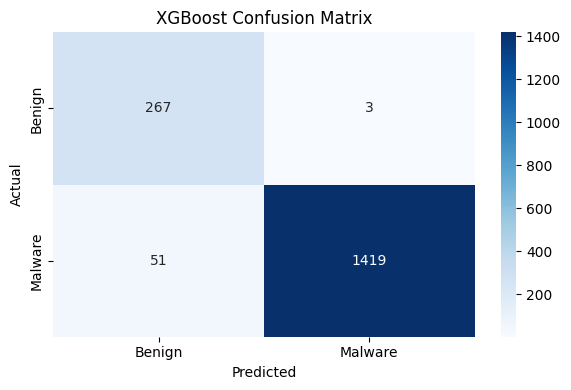

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malware'], yticklabels=['Benign', 'Malware'])
plt.title(f"{MODEL_NAME} Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

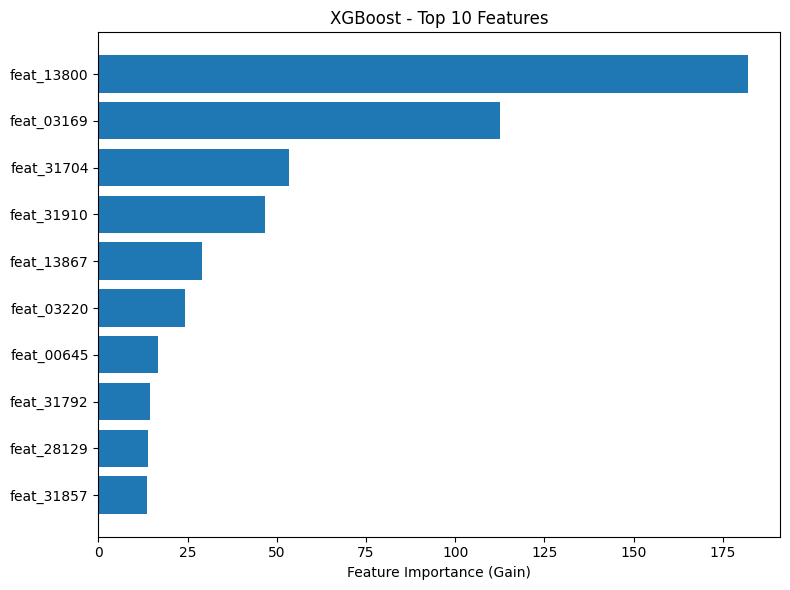

In [12]:
TOP_K_FEATURES = 10
import matplotlib.pyplot as plt
import pandas as pd
import os

booster = xgb_model.get_booster()
booster.feature_names = feature_cols
scores = booster.get_score(importance_type='gain')

df_imp = pd.DataFrame({'feature': list(scores.keys()), 'importance': list(scores.values())})
df_imp = df_imp.sort_values('importance', ascending=False).head(TOP_K_FEATURES)

plt.figure(figsize=(8, 6))
plt.barh(df_imp['feature'][::-1], df_imp['importance'][::-1])
plt.xlabel('Feature Importance (Gain)')
plt.title('XGBoost - Top 10 Features')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()